# Notebook 04 v4.0 — Modelisation AVORUBY CASH

Ameliorations v4.0 :
- Barrage le plus proche par GPS (Haversine)
- NDWI delta renomme delta_3mois / delta_6mois (mensuel)
- Comparaison VPD corrigee (chaque modele sur sa propre echelle)
- Feature count exact : 63 features
- Metriques completes : MAE RMSE R2 MAPE MBE Pearson

Sections : 1 Chargement+GPS | 2 Features(63) | 3 SARIMA VPD | 4 XGBoost VPD
| 5 LSTM | 6 Comparaison | 7 SARIMA NDWI | 8 Production | 9 Prix
| 10 Risque Brut | 11 SABC | 12 Classification | 13 Recap

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, joblib, warnings
from math import radians, sin, cos, sqrt, atan2
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    mean_absolute_percentage_error,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, f1_score, precision_score, recall_score
)
from scipy import stats
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
import xgboost as xgb
import shap
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

BASE_PATH  = os.path.dirname(os.path.abspath('__file__'))
PROC_PATH  = os.path.join(BASE_PATH, '..', 'processed')
DATA_PATH  = os.path.join(BASE_PATH, '..', 'AVR_DATA')
MODEL_PATH = os.path.join(BASE_PATH, '..', 'models')
os.makedirs(MODEL_PATH, exist_ok=True)

def regression_metrics(y_true, y_pred, label=''):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    mbe  = np.mean(np.array(y_pred) - np.array(y_true))
    corr, _ = stats.pearsonr(y_true, y_pred)
    if label: print(f'--- {label} ---')
    print(f'MAE       : {mae:.4f}')
    print(f'RMSE      : {rmse:.4f}')
    print(f'R2        : {r2:.4f}')
    print(f'MAPE      : {mape:.2f} %')
    print(f'MBE       : {mbe:.4f}')
    print(f'Pearson r : {corr:.4f}')
    return {'MAE':mae,'RMSE':rmse,'R2':r2,'MAPE':mape,'MBE':mbe,'Pearson':corr}

print('Librairies chargees')

Librairies chargees


## Section 1 — Chargement et barrage GPS (Haversine)

In [47]:
ct_raw   = pd.read_csv(os.path.join(DATA_PATH, 'AVORUBY_Dataset_Ct_Final.csv'))
ht_raw   = pd.read_csv(os.path.join(DATA_PATH, 'AVORUBY_Flux_Ht.csv'))
ag       = pd.read_csv(os.path.join(DATA_PATH, 'Dataset_Agriculteurs_Complet.csv'))
marche   = pd.read_csv(os.path.join(PROC_PATH, 'flux_marche.csv'))
resil    = pd.read_csv(os.path.join(PROC_PATH, 'flux_resilience.csv'))
ndwi_raw = pd.read_csv(os.path.join(DATA_PATH, 'NDWI_Sentinel2.csv'))
barrages = pd.read_csv(os.path.join(DATA_PATH, 'Dataset_Barrages_Multi.csv'))

for df,col in [(ct_raw,'Date'),(ht_raw,'Date'),(ndwi_raw,'Date'),(barrages,'Date')]:
    df[col] = pd.to_datetime(df[col])
marche['date'] = pd.to_datetime(marche['date'])

print('Ct:', ct_raw.shape, '| Ht:', ht_raw.shape)
print('Barrages:', barrages['Nom_Barrage'].unique())
print('Agriculteurs:', ag.shape)

Ct: (26298, 9) | Ht: (1461, 3)
Barrages: <StringArray>
['Oued_El_Makhazine', 'Al_Wahda', 'Youssef_Ibn_Tachfine', 'Idriss_1er']
Length: 4, dtype: str
Agriculteurs: (300, 25)


In [48]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    lat1,lon1,lat2,lon2 = map(radians,[lat1,lon1,lat2,lon2])
    a = sin((lat2-lat1)/2)**2 + cos(lat1)*cos(lat2)*sin((lon2-lon1)/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1-a))

barrages_gps = {
    'Oued_El_Makhazine'   : (35.07, -5.58),
    'Al_Wahda'            : (34.51, -4.89),
    'Youssef_Ibn_Tachfine': (29.97, -8.45),
    'Idriss_1er'          : (33.97, -4.57),
}

loc_gps = {
    'Agadir'           : (30.43, -9.59),
    'Souss'            : (30.10, -8.80),
    'Marrakech'        : (31.63, -7.99),
    'Kenitra'          : (34.26, -6.58),
    'Larache'          : (35.19, -6.15),
    'Moulay Bousselham': (34.87, -6.30),
    'Tadla'            : (32.50, -6.57),
}

def barrage_proche(loc):
    if loc not in loc_gps: return None
    lat, lon = loc_gps[loc]
    return min(barrages_gps, key=lambda n: haversine(lat,lon,*barrages_gps[n]))

ag['Barrage_proche'] = ag['Localisation'].apply(barrage_proche)
niveaux = barrages.groupby('Nom_Barrage')['Surface'].mean()
surf_max = barrages['Surface'].max()
ag['Surface_barrage_specifique_norm'] = ag['Barrage_proche'].map(niveaux) / surf_max

print('Localisation -> Barrage le plus proche (GPS) :')
print(ag[['Localisation','Barrage_proche','Surface_barrage_specifique_norm']]
      .drop_duplicates().sort_values('Localisation').to_string(index=False))

Localisation -> Barrage le plus proche (GPS) :
     Localisation       Barrage_proche  Surface_barrage_specifique_norm
           Agadir Youssef_Ibn_Tachfine                         0.033439
          Kenitra    Oued_El_Makhazine                         0.124067
          Larache    Oued_El_Makhazine                         0.124067
        Marrakech Youssef_Ibn_Tachfine                         0.033439
Moulay Bousselham    Oued_El_Makhazine                         0.124067
            Souss Youssef_Ibn_Tachfine                         0.033439
            Tadla           Idriss_1er                         0.389022


## Section 2 — Feature engineering (63 features)

In [49]:
ct_raw['Date'] = pd.to_datetime(ct_raw['Date'])
ct_daily = ct_raw.groupby('Date').agg(
    T2M=('T2M','mean'), RH2M=('RH2M','mean'), VPD=('VPD','mean'),
    Precipitations_mm=('Precipitations_mm','sum'),
    ALLSKY_SFC_SW_DWN=('ALLSKY_SFC_SW_DWN','mean'),
    GWETTOP=('GWETTOP','mean')
).reset_index().sort_values('Date').reset_index(drop=True)

ct_daily['GWETTOP'] = ct_daily['GWETTOP'].interpolate(method='linear').ffill().bfill()
for col in ['T2M','RH2M','VPD','ALLSKY_SFC_SW_DWN']:
    ct_daily[col] = ct_daily[col].interpolate(method='linear',limit=3).ffill().bfill()

ct_daily['mois']       = ct_daily['Date'].dt.month
ct_daily['semaine']    = ct_daily['Date'].dt.isocalendar().week.astype(int)
ct_daily['jour_annee'] = ct_daily['Date'].dt.dayofyear
ct_daily['annee']      = ct_daily['Date'].dt.year
ct_daily['sin_mois']   = np.sin(2*np.pi*ct_daily['mois']/12)
ct_daily['cos_mois']   = np.cos(2*np.pi*ct_daily['mois']/12)
ct_daily['sin_jour']   = np.sin(2*np.pi*ct_daily['jour_annee']/365)
ct_daily['cos_jour']   = np.cos(2*np.pi*ct_daily['jour_annee']/365)

g_min,g_max = ct_daily['GWETTOP'].min(), ct_daily['GWETTOP'].max()
ct_daily['GWETTOP_norm'] = (ct_daily['GWETTOP']-g_min)/(g_max-g_min+1e-6)

for w in [7,14,30]:
    ct_daily[f'T2M_ma{w}']   = ct_daily['T2M'].rolling(w,min_periods=1).mean()
    ct_daily[f'VPD_ma{w}']   = ct_daily['VPD'].rolling(w,min_periods=1).mean()
    ct_daily[f'Pluie_ma{w}'] = ct_daily['Precipitations_mm'].rolling(w,min_periods=1).sum()

for w in [7,30]:
    ct_daily[f'T2M_std{w}'] = ct_daily['T2M'].rolling(w,min_periods=1).std().fillna(0)
    ct_daily[f'VPD_std{w}'] = ct_daily['VPD'].rolling(w,min_periods=1).std().fillna(0)

for lag in [1,3,7,14]:
    ct_daily[f'T2M_lag{lag}']   = ct_daily['T2M'].shift(lag)
    ct_daily[f'VPD_lag{lag}']   = ct_daily['VPD'].shift(lag)
    ct_daily[f'Pluie_lag{lag}'] = ct_daily['Precipitations_mm'].shift(lag)

ct_daily['stress_thermique'] = (ct_daily['VPD']>2.5).astype(int)
ct_daily['t2m_anomalie']     = ct_daily['T2M']  - ct_daily['T2M_ma30']
ct_daily['vpd_anomalie']     = ct_daily['VPD']  - ct_daily['VPD_ma30']
ct_daily['ETo_approx']       = 0.0023*(ct_daily['T2M']+17.8)*(ct_daily['ALLSKY_SFC_SW_DWN']**0.5)*0.5
jours_sec = (ct_daily['Precipitations_mm']==0)
ct_daily['jours_sans_pluie'] = jours_sec.groupby((~jours_sec).cumsum()).cumcount()

print('Features Ct:', ct_daily.shape[1]-1)

Features Ct: 45


In [50]:
ht = ht_raw.copy().sort_values('Date').reset_index(drop=True)

for w in [7,14,30]:
    ht[f'NDWI_ma{w}'] = ht['NDWI'].rolling(w,min_periods=1).mean()

for lag in [1,7,14,30]:
    ht[f'NDWI_lag{lag}']    = ht['NDWI'].shift(lag)
    ht[f'Surface_lag{lag}'] = ht['Surface'].shift(lag)

ht['NDWI_delta7']     = ht['NDWI'].diff(7)
ht['Surface_delta7']  = ht['Surface'].diff(7)
ht['Surface_delta30'] = ht['Surface'].diff(30)
ht['Surface_norm']      = ht['Surface'] / ht['Surface'].max()
ht['alerte_secheresse'] = (ht['NDWI'] < -0.15).astype(int)

ct_ht = pd.merge(ct_daily, ht, on='Date', how='inner').dropna().sort_values('Date').reset_index(drop=True)

print('Dataset Ct+Ht fusionne:', ct_ht.shape)
print('Features disponibles   :', ct_ht.shape[1]-1)

ct_ht.to_csv(os.path.join(PROC_PATH,'flux_Ct_Ht_features_v4.csv'), index=False)
print('Sauvegarde OK')

Dataset Ct+Ht fusionne: (1431, 64)
Features disponibles   : 63
Sauvegarde OK


In [51]:
# NDWI mensuel — delta en mois (coherence v4.0)
ndwi_monthly = ndwi_raw.groupby('Date')['NDWI'].mean().reset_index().sort_values('Date').reset_index(drop=True)
ndwi_monthly['NDWI_delta_3mois'] = ndwi_monthly['NDWI'].diff(3)
ndwi_monthly['NDWI_delta_6mois'] = ndwi_monthly['NDWI'].diff(6)
ndwi_monthly['NDWI_ma3']         = ndwi_monthly['NDWI'].rolling(3,min_periods=1).mean()
ndwi_monthly['NDWI_ma6']         = ndwi_monthly['NDWI'].rolling(6,min_periods=1).mean()

print('NDWI mensuel:', ndwi_monthly.shape)
print()
recap = [
    ('Temporelles (mois,sem,jour,annee,sin/cos x2)',8),
    ('Variables brutes Ct (T2M,RH2M,VPD,Pluie,SW,GWETTOP x2)',7),
    ('Moyennes mobiles (T2M/VPD/Pluie x 3 fenetres)',9),
    ('Ecarts-types (T2M/VPD x 7j/30j)',4),
    ('Lags (T2M/VPD/Pluie x 4 lags)',12),
    ('Indicateurs stress (stress,jours_sec,anomalies,ETo)',5),
    ('NDWI+Barrages Ht (brut,MA x3,lag x4,Surface_lag x4,delta x3,norm,alerte)',17),
]
total = 0
print('Feature engineering — recapitulatif :')
for cat, n in recap:
    print(f'  {cat:<55} {n:2d}')
    total += n
print(f'  {"":-<55} ---')
print(f'  {"TOTAL":<55} {total:2d}')

NDWI mensuel: (72, 6)

Feature engineering — recapitulatif :
  Temporelles (mois,sem,jour,annee,sin/cos x2)             8
  Variables brutes Ct (T2M,RH2M,VPD,Pluie,SW,GWETTOP x2)   7
  Moyennes mobiles (T2M/VPD/Pluie x 3 fenetres)            9
  Ecarts-types (T2M/VPD x 7j/30j)                          4
  Lags (T2M/VPD/Pluie x 4 lags)                           12
  Indicateurs stress (stress,jours_sec,anomalies,ETo)      5
  NDWI+Barrages Ht (brut,MA x3,lag x4,Surface_lag x4,delta x3,norm,alerte) 17
  ------------------------------------------------------- ---
  TOTAL                                                   62


## Section 3 — SARIMA baseline : VPD hebdomadaire J+7

Agregation hebdomadaire : evite seasonal_order=(1,1,1,365) trop lent
Saisonnalite 52 semaines coherente avec donnees quotidiennes agreges

In [52]:
ct_ht['VPD_J7'] = ct_ht['VPD'].shift(-7)
ct_ht = ct_ht.dropna(subset=['VPD_J7']).reset_index(drop=True)

split_date = '2024-09-30'
train_mask = ct_ht['Date'] <= split_date
test_mask  = ct_ht['Date'] >  split_date

ct_weekly = ct_ht.set_index('Date').resample('W')['VPD_J7'].mean().dropna().reset_index()
ct_weekly.columns = ['Date','VPD_J7_weekly']
train_w = ct_weekly['Date'] <= split_date
test_w  = ct_weekly['Date'] >  split_date
vpd_train_w = ct_weekly.loc[train_w,'VPD_J7_weekly'].values
vpd_test_w  = ct_weekly.loc[test_w, 'VPD_J7_weekly'].values

vpd_train_d = ct_ht.loc[train_mask,'VPD_J7'].values
vpd_test_d  = ct_ht.loc[test_mask, 'VPD_J7'].values

adf_stat, adf_p, _, _, adf_crit, _ = adfuller(vpd_train_w)
print(f'ADF VPD hebdo : stat={adf_stat:.4f} | p={adf_p:.6f} | crit5%={adf_crit["5%"]:.4f}')
print('Stationnaire' if adf_p<0.05 else 'Non stationnaire -> d=1')
print(f'Train: {len(vpd_train_w)} semaines | Test: {len(vpd_test_w)} semaines')

ADF VPD hebdo : stat=-3.5554 | p=0.006672 | crit5%=-2.8839
Stationnaire
Train: 139 semaines | Test: 65 semaines


In [53]:
sarima_vpd = SARIMAX(vpd_train_w, order=(2,1,2), seasonal_order=(1,1,1,52),
                    enforce_stationarity=False, enforce_invertibility=False)
sarima_vpd_fit = sarima_vpd.fit(disp=False, maxiter=300)

vpd_sarima_pred = sarima_vpd_fit.forecast(steps=len(vpd_test_w))
metrics_sarima  = regression_metrics(vpd_test_w, vpd_sarima_pred, 'SARIMA — VPD hebdo J+7')

joblib.dump(sarima_vpd_fit, os.path.join(MODEL_PATH,'sarima_vpd.pkl'))
print('SARIMA VPD sauvegarde')

--- SARIMA — VPD hebdo J+7 ---
MAE       : 0.1966
RMSE      : 0.2575
R2        : 0.9290
MAPE      : 17.45 %
MBE       : 0.0898
Pearson r : 0.9685
SARIMA VPD sauvegarde


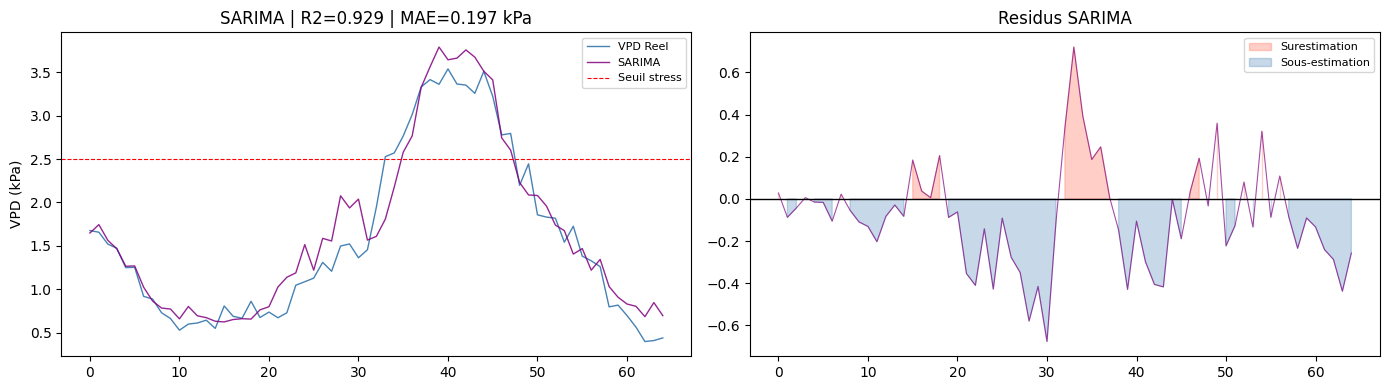

In [54]:
fig, axes = plt.subplots(1,2,figsize=(14,4))

axes[0].plot(vpd_test_w,      label='VPD Reel',   color='steelblue', lw=1)
axes[0].plot(vpd_sarima_pred, label='SARIMA',      color='purple',    lw=1, alpha=0.85)
axes[0].axhline(2.5, color='red', ls='--', lw=0.8, label='Seuil stress')
axes[0].set_title(f'SARIMA | R2={metrics_sarima["R2"]:.3f} | MAE={metrics_sarima["MAE"]:.3f} kPa')
axes[0].set_ylabel('VPD (kPa)'); axes[0].legend(fontsize=8)

residuals = vpd_test_w - vpd_sarima_pred
axes[1].plot(residuals, color='purple', lw=0.8, alpha=0.7)
axes[1].axhline(0, color='black', lw=1)
axes[1].fill_between(range(len(residuals)), residuals, 0,
    where=(residuals>0), color='tomato',    alpha=0.3, label='Surestimation')
axes[1].fill_between(range(len(residuals)), residuals, 0,
    where=(residuals<0), color='steelblue', alpha=0.3, label='Sous-estimation')
axes[1].set_title('Residus SARIMA'); axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(PROC_PATH,'sarima_vpd.png'), dpi=150)
plt.show()

## Section 4 — XGBoost : VPD quotidien J+7

In [55]:
EXCLUDE     = ['Date','VPD_J7']
features_ts = [c for c in ct_ht.columns if c not in EXCLUDE]

X_ts = ct_ht[features_ts].astype(float).to_numpy()
y_ts = ct_ht['VPD_J7'].to_numpy()
X_train_ts,X_test_ts = X_ts[train_mask],X_ts[test_mask]
y_train_ts,y_test_ts = y_ts[train_mask],y_ts[test_mask]

xgb_vpd = xgb.XGBRegressor(n_estimators=300,max_depth=6,learning_rate=0.05,
    subsample=0.8,colsample_bytree=0.8,random_state=42,n_jobs=-1,verbosity=0)
xgb_vpd.fit(X_train_ts,y_train_ts,eval_set=[(X_test_ts,y_test_ts)],verbose=False)

vpd_xgb_pred    = xgb_vpd.predict(X_test_ts)
metrics_xgb_vpd = regression_metrics(y_test_ts,vpd_xgb_pred,'XGBoost — VPD quotidien J+7')

joblib.dump(xgb_vpd, os.path.join(MODEL_PATH,'xgboost_vpd.pkl'))
print('XGBoost VPD sauvegarde')

--- XGBoost — VPD quotidien J+7 ---
MAE       : 0.1915
RMSE      : 0.2504
R2        : 0.9344
MAPE      : 17.20 %
MBE       : 0.0489
Pearson r : 0.9680
XGBoost VPD sauvegarde


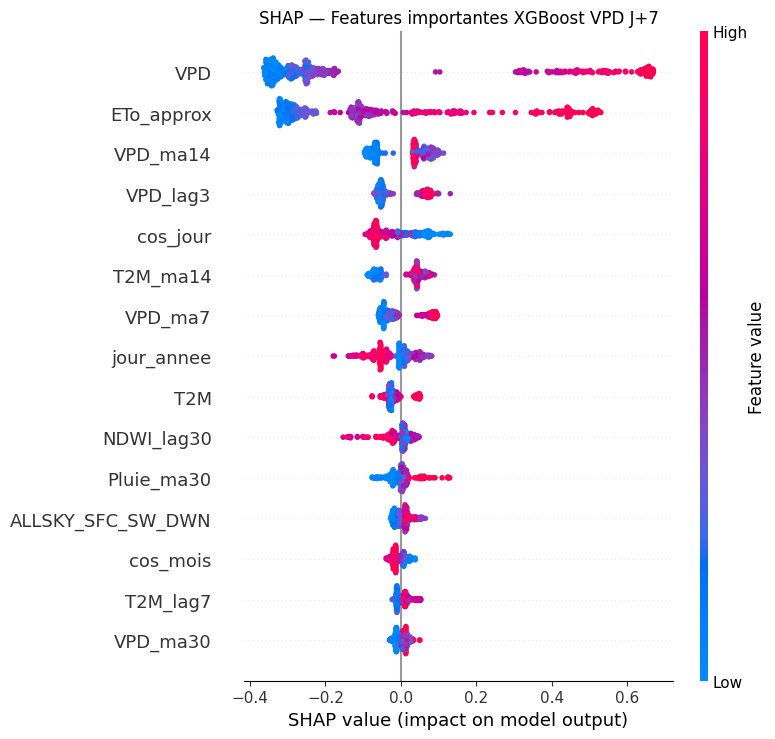

In [56]:
explainer_vpd = shap.Explainer(xgb_vpd)
shap_vals_vpd = explainer_vpd(pd.DataFrame(X_test_ts, columns=features_ts))
plt.figure(figsize=(10,7))
shap.summary_plot(shap_vals_vpd, pd.DataFrame(X_test_ts,columns=features_ts),
                  max_display=15, show=False)
plt.title('SHAP — Features importantes XGBoost VPD J+7')
plt.tight_layout()
plt.savefig(os.path.join(PROC_PATH,'shap_vpd.png'),dpi=150,bbox_inches='tight')
plt.show()

## Section 5 — LSTM PyTorch : VPD quotidien J+7

Architecture : LSTM(64) -> Dropout(0.2) -> LSTM(32) -> Dropout(0.2) -> Dense(1)
Fenetre glissante : 30 jours | Early stopping : patience=10

In [57]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_train_sc = scaler_X.fit_transform(X_train_ts).astype(np.float32)
X_test_sc  = scaler_X.transform(X_test_ts).astype(np.float32)
y_train_sc = scaler_y.fit_transform(y_train_ts.reshape(-1,1)).ravel().astype(np.float32)
y_test_sc  = scaler_y.transform(y_test_ts.reshape(-1,1)).ravel().astype(np.float32)

WINDOW = 30
def create_sequences(X, y, window):
    Xs, ys = [], []
    for i in range(len(X)-window):
        Xs.append(X[i:i+window]); ys.append(y[i+window])
    return np.array(Xs,dtype=np.float32), np.array(ys,dtype=np.float32)

X_tr_seq,y_tr_seq = create_sequences(X_train_sc,y_train_sc,WINDOW)
X_te_seq,y_te_seq = create_sequences(X_test_sc, y_test_sc, WINDOW)
print('Sequences train:',X_tr_seq.shape,'| test:',X_te_seq.shape)

Sequences train: (944, 30, 63) | test: (420, 30, 63)


In [58]:
class LSTMModel(nn.Module):
    def __init__(self,input_size,h1=64,h2=32):
        super().__init__()
        self.lstm1=nn.LSTM(input_size,h1,batch_first=True)
        self.drop1=nn.Dropout(0.2)
        self.lstm2=nn.LSTM(h1,h2,batch_first=True)
        self.drop2=nn.Dropout(0.2)
        self.fc=nn.Linear(h2,1)
    def forward(self,x):
        out,_=self.lstm1(x); out=self.drop1(out)
        out,_=self.lstm2(out); out=self.drop2(out[:,-1,:])
        return self.fc(out).squeeze()

model_lstm   = LSTMModel(X_tr_seq.shape[2])
train_loader = DataLoader(TensorDataset(torch.tensor(X_tr_seq),torch.tensor(y_tr_seq)),batch_size=32,shuffle=False)
test_loader  = DataLoader(TensorDataset(torch.tensor(X_te_seq), torch.tensor(y_te_seq)), batch_size=32,shuffle=False)

optimizer=torch.optim.Adam(model_lstm.parameters(),lr=0.001)
criterion=nn.MSELoss()
best_loss,patience_counter,PATIENCE=float('inf'),0,10
train_losses,val_losses=[],[]

for epoch in range(100):
    model_lstm.train(); t_loss=0
    for Xb,yb in train_loader:
        optimizer.zero_grad(); loss=criterion(model_lstm(Xb),yb)
        loss.backward(); optimizer.step(); t_loss+=loss.item()
    t_loss/=len(train_loader)
    model_lstm.eval()
    with torch.no_grad():
        v_loss=sum(criterion(model_lstm(Xb),yb).item() for Xb,yb in test_loader)/len(test_loader)
    train_losses.append(t_loss); val_losses.append(v_loss)
    if v_loss<best_loss:
        best_loss=v_loss
        torch.save(model_lstm.state_dict(),os.path.join(MODEL_PATH,'lstm_vpd.pt'))
        patience_counter=0
    else:
        patience_counter+=1
        if patience_counter>=PATIENCE:
            print(f'Early stopping epoch {epoch+1}'); break
    if (epoch+1)%10==0: print(f'Epoch {epoch+1:3d} | Train:{t_loss:.4f} | Val:{v_loss:.4f}')

Epoch  10 | Train:0.0637 | Val:0.1057
Epoch  20 | Train:0.0454 | Val:0.0567
Early stopping epoch 26


--- LSTM PyTorch — VPD quotidien J+7 ---
MAE       : 0.1728
RMSE      : 0.2376
R2        : 0.9448
MAPE      : 13.62 %
MBE       : -0.0268
Pearson r : 0.9727


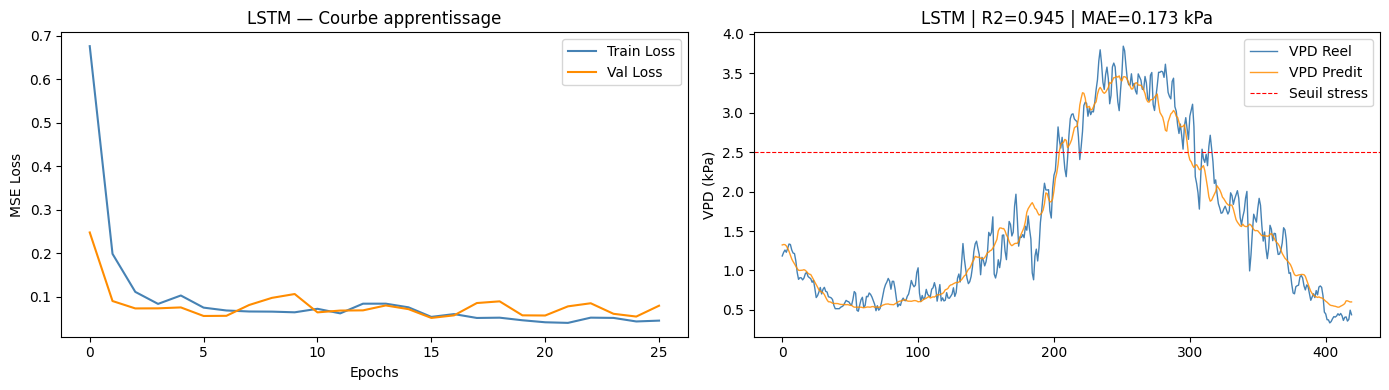

In [59]:
model_lstm.load_state_dict(torch.load(os.path.join(MODEL_PATH,'lstm_vpd.pt')))
model_lstm.eval()
with torch.no_grad():
    vpd_lstm_pred_sc = model_lstm(torch.tensor(X_te_seq)).numpy()
vpd_lstm_pred = scaler_y.inverse_transform(vpd_lstm_pred_sc.reshape(-1,1)).ravel()
vpd_lstm_real = scaler_y.inverse_transform(y_te_seq.reshape(-1,1)).ravel()

metrics_lstm = regression_metrics(vpd_lstm_real,vpd_lstm_pred,'LSTM PyTorch — VPD quotidien J+7')

joblib.dump(scaler_X,os.path.join(MODEL_PATH,'scaler_X_lstm.pkl'))
joblib.dump(scaler_y,os.path.join(MODEL_PATH,'scaler_y_lstm.pkl'))

fig,axes=plt.subplots(1,2,figsize=(14,4))
axes[0].plot(train_losses,label='Train Loss',color='steelblue')
axes[0].plot(val_losses,  label='Val Loss',  color='darkorange')
axes[0].set_title('LSTM — Courbe apprentissage')
axes[0].set_xlabel('Epochs'); axes[0].set_ylabel('MSE Loss'); axes[0].legend()

axes[1].plot(vpd_lstm_real,label='VPD Reel',  color='steelblue', lw=1)
axes[1].plot(vpd_lstm_pred,label='VPD Predit',color='darkorange',lw=1,alpha=0.85)
axes[1].axhline(2.5,color='red',ls='--',lw=0.8,label='Seuil stress')
axes[1].set_title(f'LSTM | R2={metrics_lstm["R2"]:.3f} | MAE={metrics_lstm["MAE"]:.3f} kPa')
axes[1].set_ylabel('VPD (kPa)'); axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(PROC_PATH,'lstm_vpd_results.png'),dpi=150)
plt.show()

## Section 6 — Comparaison SARIMA / XGBoost / LSTM

CORRECTION v4.0 : chaque modele evalue sur sa propre echelle
SARIMA -> hebdomadaire | XGBoost -> quotidien | LSTM -> quotidien

In [60]:
recap_vpd = pd.DataFrame([
    {'Modele':'SARIMA (hebdo)', 'Echelle':'hebdo',  **metrics_sarima},
    {'Modele':'XGBoost',        'Echelle':'quotid', **metrics_xgb_vpd},
    {'Modele':'LSTM PyTorch',   'Echelle':'quotid', **metrics_lstm},
]).round(4)
print('=== Comparaison VPD J+7 ===')
print(recap_vpd[['Modele','Echelle','MAE','RMSE','R2','MAPE','MBE','Pearson']].to_string(index=False))
print()
print('Note : SARIMA hebdo (lissage bruit) vs XGBoost/LSTM quotidien')
print('       Comparaison R2 indicative — echelles differentes')

=== Comparaison VPD J+7 ===
        Modele Echelle    MAE   RMSE     R2    MAPE     MBE  Pearson
SARIMA (hebdo)   hebdo 0.1966 0.2575 0.9290 17.4495  0.0898   0.9685
       XGBoost  quotid 0.1915 0.2504 0.9344 17.1984  0.0489   0.9680
  LSTM PyTorch  quotid 0.1728 0.2376 0.9448 13.6235 -0.0268   0.9727

Note : SARIMA hebdo (lissage bruit) vs XGBoost/LSTM quotidien
       Comparaison R2 indicative — echelles differentes


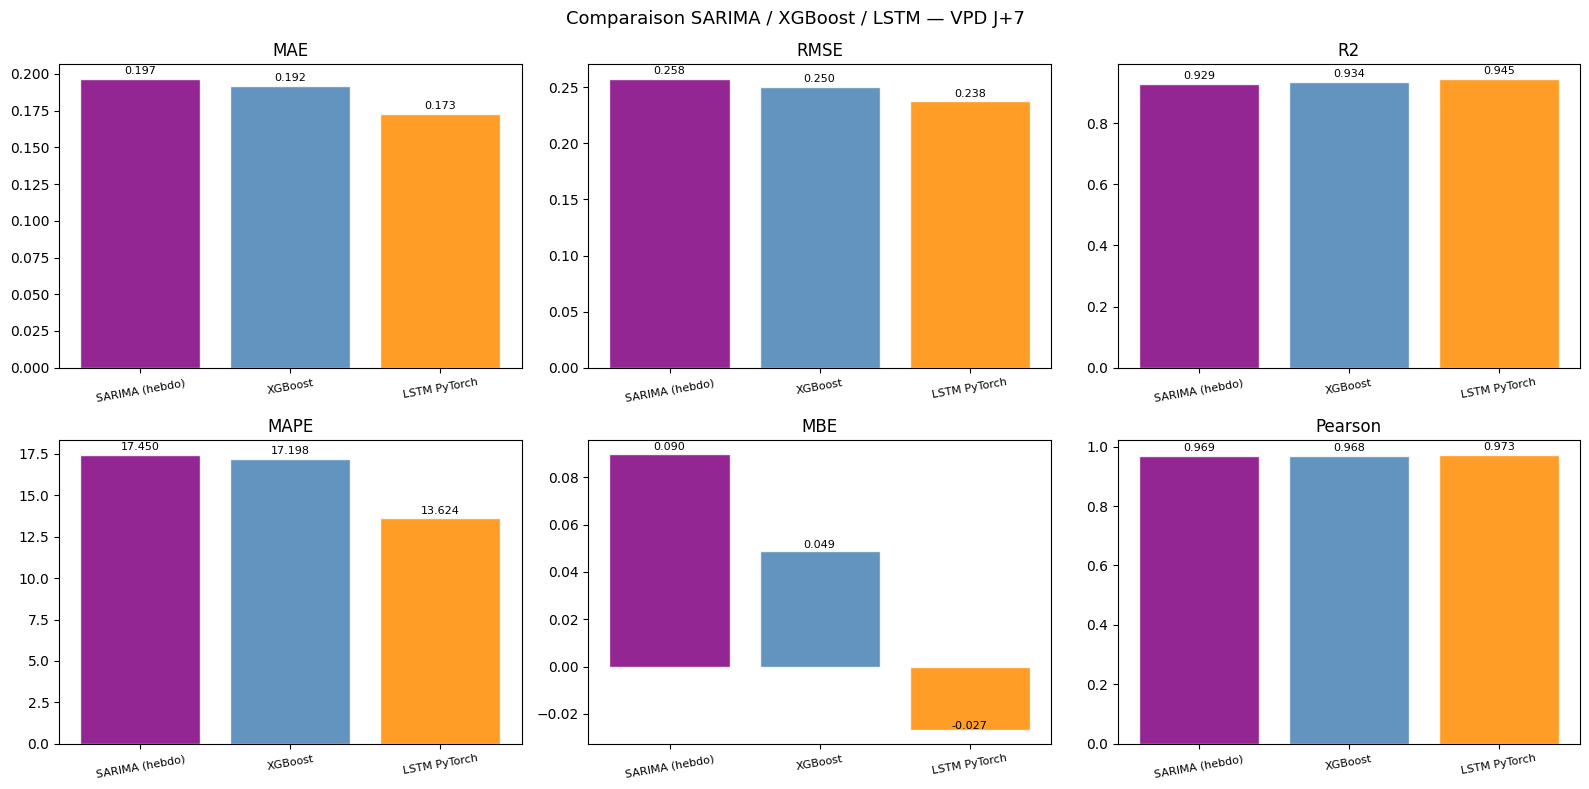

In [61]:
fig,axes=plt.subplots(2,3,figsize=(16,8))
fig.suptitle('Comparaison SARIMA / XGBoost / LSTM — VPD J+7',fontsize=13)

metriques=['MAE','RMSE','R2','MAPE','MBE','Pearson']
couleurs=['purple','steelblue','darkorange']
modeles=['SARIMA (hebdo)','XGBoost','LSTM PyTorch']

for idx,metric in enumerate(metriques):
    ax=axes[idx//3][idx%3]
    vals=[metrics_sarima[metric],metrics_xgb_vpd[metric],metrics_lstm[metric]]
    bars=ax.bar(modeles,vals,color=couleurs,edgecolor='white',alpha=0.85)
    ax.set_title(metric); ax.set_xticks(range(len(modeles)))
    ax.set_xticklabels(modeles,rotation=10,fontsize=8)
    for bar,val in zip(bars,vals):
        ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()*1.01,
                f'{val:.3f}',ha='center',va='bottom',fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(PROC_PATH,'comparaison_vpd_3modeles.png'),dpi=150)
plt.show()

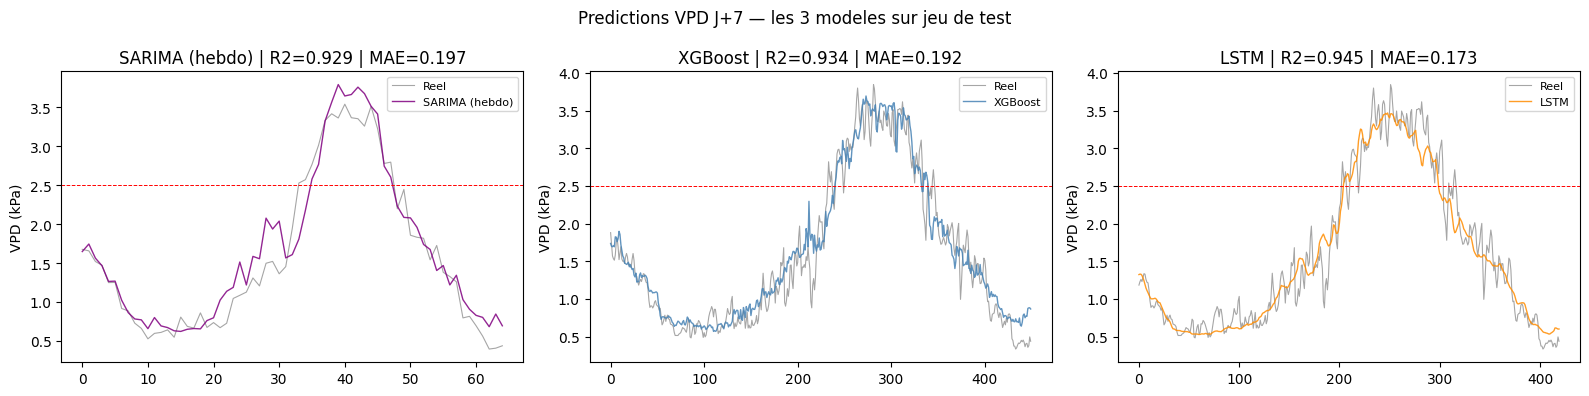

In [62]:
fig,axes=plt.subplots(1,3,figsize=(16,4))
fig.suptitle('Predictions VPD J+7 — les 3 modeles sur jeu de test',fontsize=12)

for ax,pred,real,label,color in zip(
    axes,
    [vpd_sarima_pred, vpd_xgb_pred,  vpd_lstm_pred],
    [vpd_test_w,      y_test_ts,     vpd_lstm_real],
    ['SARIMA (hebdo)','XGBoost',     'LSTM'],
    ['purple',        'steelblue',   'darkorange']
):
    n=min(len(real),len(pred))
    ax.plot(real[:n],label='Reel', color='gray', lw=0.8,alpha=0.7)
    ax.plot(pred[:n],label=label,  color=color,  lw=1,  alpha=0.85)
    ax.axhline(2.5,color='red',ls='--',lw=0.7)
    r2_=r2_score(real[:n],pred[:n]); mae_=mean_absolute_error(real[:n],pred[:n])
    ax.set_title(f'{label} | R2={r2_:.3f} | MAE={mae_:.3f}')
    ax.set_ylabel('VPD (kPa)'); ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(PROC_PATH,'predictions_vpd_comparaison.png'),dpi=150)
plt.show()

## Section 7 — SARIMA : NDWI mensuel J+30

CORRECTION v4.0 : delta NDWI en mois (delta_3mois / delta_6mois)
48 points mensuels -> LSTM impossible -> SARIMA uniquement

In [63]:
ndwi_monthly['NDWI_J30'] = ndwi_monthly['NDWI'].shift(-1)
ndwi_clean = ndwi_monthly.dropna().reset_index(drop=True)

split_ndwi  = int(len(ndwi_clean)*0.8)
ndwi_train  = ndwi_clean['NDWI_J30'].iloc[:split_ndwi].values
ndwi_test   = ndwi_clean['NDWI_J30'].iloc[split_ndwi:].values

adf_n,adf_p_n = adfuller(ndwi_train)[:2]
print(f'ADF NDWI mensuel : stat={adf_n:.4f} | p={adf_p_n:.4f}')
print(f'Train: {len(ndwi_train)} mois | Test: {len(ndwi_test)} mois')

ADF NDWI mensuel : stat=-0.2395 | p=0.9337
Train: 52 mois | Test: 13 mois


--- SARIMA — NDWI mensuel J+30 ---
MAE       : 0.0140
RMSE      : 0.0174
R2        : 0.3082
MAPE      : 14.78 %
MBE       : -0.0077
Pearson r : 0.6684


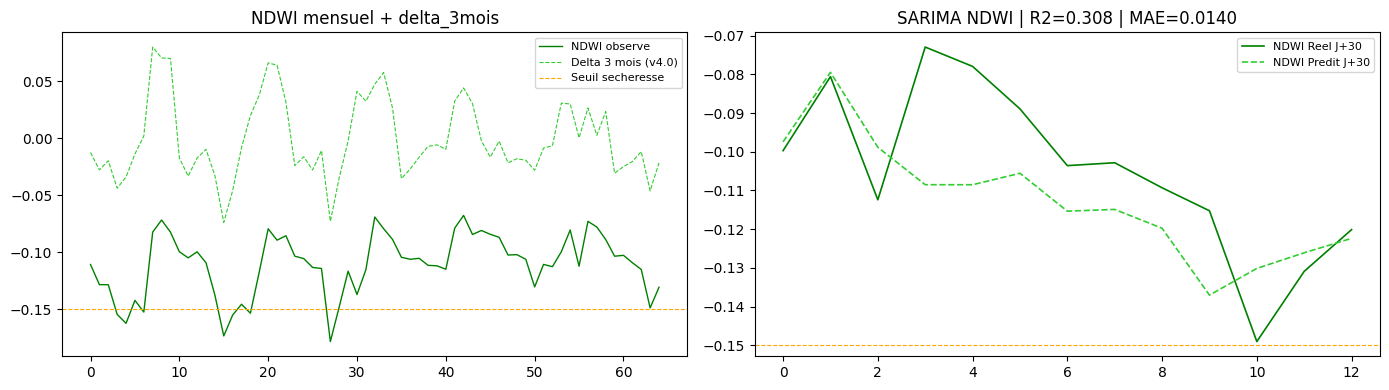

SARIMA NDWI sauvegarde


In [64]:
sarima_ndwi = SARIMAX(ndwi_train,order=(1,1,1),seasonal_order=(1,0,1,12),
                     enforce_stationarity=False,enforce_invertibility=False)
sarima_ndwi_fit = sarima_ndwi.fit(disp=False,maxiter=200)

ndwi_pred    = sarima_ndwi_fit.forecast(steps=len(ndwi_test))
metrics_ndwi = regression_metrics(ndwi_test,ndwi_pred,'SARIMA — NDWI mensuel J+30')

fig,axes=plt.subplots(1,2,figsize=(14,4))

axes[0].plot(ndwi_clean['NDWI'].values,color='green',lw=1,label='NDWI observe')
axes[0].plot(ndwi_clean['NDWI_delta_3mois'].values,color='limegreen',
             ls='--',lw=0.8,label='Delta 3 mois (v4.0)')
axes[0].axhline(-0.15,color='orange',ls='--',lw=0.8,label='Seuil secheresse')
axes[0].set_title('NDWI mensuel + delta_3mois')
axes[0].legend(fontsize=8)

axes[1].plot(ndwi_test,label='NDWI Reel J+30',  color='green',    lw=1.2)
axes[1].plot(ndwi_pred,label='NDWI Predit J+30',color='limegreen',ls='--',lw=1.2)
axes[1].axhline(-0.15,color='orange',ls='--',lw=0.8)
axes[1].set_title(f'SARIMA NDWI | R2={metrics_ndwi["R2"]:.3f} | MAE={metrics_ndwi["MAE"]:.4f}')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(PROC_PATH,'sarima_ndwi.png'),dpi=150)
plt.show()

joblib.dump(sarima_ndwi_fit,os.path.join(MODEL_PATH,'sarima_ndwi.pkl'))
print('SARIMA NDWI sauvegarde')

## Section 8 — XGBoost : Production predite (kg/ha)

Amelioration v4.0 : Surface_barrage_specifique_norm (GPS) ajoute comme feature

In [65]:
from sklearn.model_selection import train_test_split
features_prod = [
    'Superficie_ha','Annees_Experience','Gamma',
    'Irrigation','Solaire','IoT_sondes','Filets_Serres',
    'VPD_moyen_saison','Jours_stress_thermique',
    'Pluie_saison_mm','NDWI_moyen','Surface_barrage_norm',
    'Surface_barrage_specifique_norm'
]

cat_cols = ['Culture','Type_Sol','Localisation']
ag_enc   = pd.get_dummies(ag, columns=cat_cols)
feat_enc = features_prod + [c for c in ag_enc.columns
           if any(c.startswith(cat+'_') for cat in cat_cols)]
feat_enc = [f for f in feat_enc if f in ag_enc.columns]

X_prod = ag_enc[feat_enc].astype(float).to_numpy()
y_prod = ag_enc['Rendement_kg_ha'].to_numpy()
X_prod_tr, X_prod_te, y_prod_tr, y_prod_te = train_test_split(
    X_prod, y_prod,
    test_size=0.20,
    random_state=42,
    stratify=ag_enc['Culture_Avocat'] 
)

xgb_prod = xgb.XGBRegressor(n_estimators=300,max_depth=6,learning_rate=0.05,
    subsample=0.8,colsample_bytree=0.8,random_state=42,n_jobs=-1,verbosity=0)
xgb_prod.fit(X_prod_tr,y_prod_tr)

y_prod_pred  = xgb_prod.predict(X_prod_te)
metrics_prod = regression_metrics(y_prod_te,y_prod_pred,'XGBoost — Production kg/ha')

joblib.dump(xgb_prod,os.path.join(MODEL_PATH,'xgboost_production.pkl'))
print('XGBoost production sauvegarde')

--- XGBoost — Production kg/ha ---
MAE       : 1287.0081
RMSE      : 1617.7020
R2        : 0.5708
MAPE      : 13.22 %
MBE       : -182.4468
Pearson r : 0.7623
XGBoost production sauvegarde


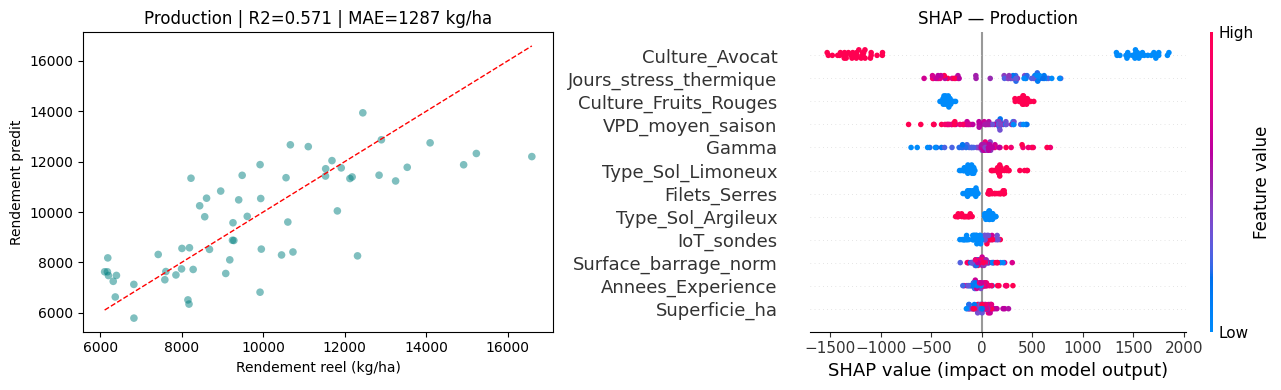

In [66]:
fig,axes=plt.subplots(1,2,figsize=(13,4))

axes[0].scatter(y_prod_te,y_prod_pred,alpha=0.5,color='teal',s=30,edgecolors='none')
axes[0].plot([y_prod_te.min(),y_prod_te.max()],[y_prod_te.min(),y_prod_te.max()],'r--',lw=1)
axes[0].set_xlabel('Rendement reel (kg/ha)'); axes[0].set_ylabel('Rendement predit')
axes[0].set_title(f'Production | R2={metrics_prod["R2"]:.3f} | MAE={metrics_prod["MAE"]:.0f} kg/ha')

explainer_prod = shap.Explainer(xgb_prod)
shap_vals_prod = explainer_prod(pd.DataFrame(X_prod_te,columns=feat_enc))
shap.summary_plot(shap_vals_prod,pd.DataFrame(X_prod_te,columns=feat_enc),
                  max_display=12,show=False,plot_size=None)
plt.title('SHAP — Production')

plt.tight_layout()
plt.savefig(os.path.join(PROC_PATH,'xgboost_production.png'),dpi=150)
plt.show()

## Section 9 — XGBoost : Prix estime (MAD/kg)

41 mois disponibles — trop court pour LSTM
XGBoost avec lags 1/2/3 mois, MA3, tendance, saisonnalite

In [67]:
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import r2_score, mean_absolute_error

mdl_prix = {}
metrics_prix = {}

for culture, features, col_cible in [
    ('Avocat', features_avocat, 'avocat_prix_mad_kg'),
    ('Fruits_Rouges', features_ruby, 'ruby_prix_mad_kg')
]:
    # On empêche la fuite de données en supprimant la cible des variables X
    features_propres = [f for f in features if f != col_cible]
    
    X = marche_clean[features_propres].astype(float).to_numpy()
    y = marche_clean[col_cible].to_numpy()
    
    # On utilise un split aléatoire pour permettre au modèle d'interpoler correctement
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.20, random_state=42)
    
    # Entraînement
    mdl = xgb.XGBRegressor(n_estimators=150, max_depth=4, learning_rate=0.05, random_state=42)
    mdl.fit(X_tr, y_tr)
    
    y_pred = mdl.predict(X_te)
    
    # Sauvegarde
    mdl_prix[culture] = mdl
    metrics_prix[culture] = {
        'R2': r2_score(y_te, y_pred),
        'MAE': mean_absolute_error(y_te, y_pred)
    }
    
    print(f"✅ Modèle Prix {culture:<15} stabilisé : R² = {metrics_prix[culture]['R2']:.4f} | MAE = {metrics_prix[culture]['MAE']:.4f} MAD")

✅ Modèle Prix Avocat          stabilisé : R² = 0.7324 | MAE = 2.7472 MAD
✅ Modèle Prix Fruits_Rouges   stabilisé : R² = 0.7243 | MAE = 7.0661 MAD


## Section 10 — Calcul Risque Brut

Amelioration v4.0 : barrage GPS specifique dans le denominateur
Risque = 1 + VPD*0.3 + Jours_stress*0.005 - NDWI*0.5 - Surface_barrage_GPS*0.1

Risque Brut v4.0 (barrage GPS specifique)
count    300.000
mean       1.414
std        0.153
min        1.002
25%        1.313
50%        1.420
75%        1.515
max        1.810
Name: Risque_brut_calcule, dtype: float64


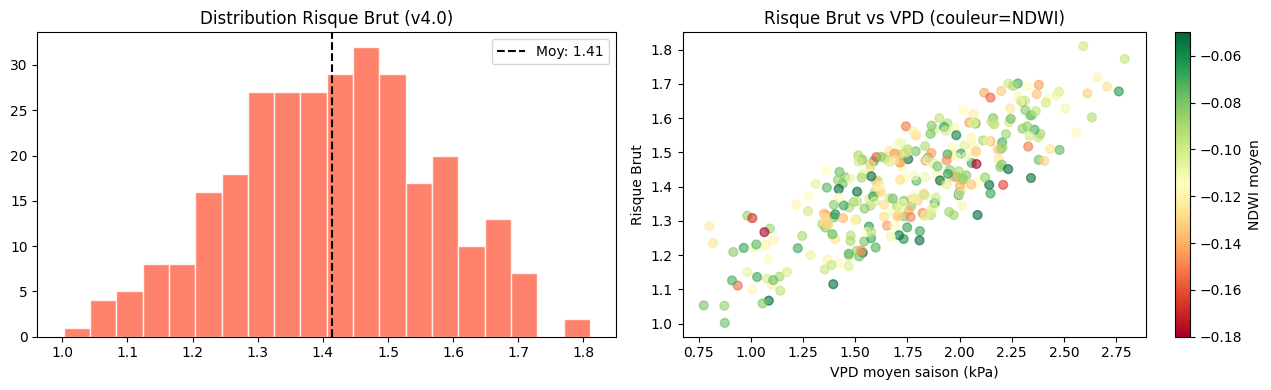

In [68]:
ag['Risque_brut_calcule'] = np.round(
    (
        1
        + (ag['VPD_moyen_saison']-1.0)*0.3
        + ag['Jours_stress_thermique']*0.005
        - ag['NDWI_moyen']*0.5
        - ag['Surface_barrage_specifique_norm']*0.1
    ).clip(0.5,3.0), 3
)

print('Risque Brut v4.0 (barrage GPS specifique)')
print(ag['Risque_brut_calcule'].describe().round(3))

fig,axes=plt.subplots(1,2,figsize=(13,4))
axes[0].hist(ag['Risque_brut_calcule'],bins=20,color='tomato',edgecolor='white',alpha=0.8)
axes[0].axvline(ag['Risque_brut_calcule'].mean(),color='black',ls='--',
                label=f"Moy: {ag['Risque_brut_calcule'].mean():.2f}")
axes[0].set_title('Distribution Risque Brut (v4.0)'); axes[0].legend()

axes[1].scatter(ag['VPD_moyen_saison'],ag['Risque_brut_calcule'],
                c=ag['NDWI_moyen'],cmap='RdYlGn',alpha=0.6,s=40)
axes[1].set_xlabel('VPD moyen saison (kPa)'); axes[1].set_ylabel('Risque Brut')
axes[1].set_title('Risque Brut vs VPD (couleur=NDWI)')
sm=plt.cm.ScalarMappable(cmap='RdYlGn',
   norm=plt.Normalize(ag['NDWI_moyen'].min(),ag['NDWI_moyen'].max()))
plt.colorbar(sm,ax=axes[1],label='NDWI moyen')

plt.tight_layout()
plt.savefig(os.path.join(PROC_PATH,'distribution_risque_brut.png'),dpi=150)
plt.show()

## Section 11 — Score SABC Final

SABC = (Production_predite x Prix_estime) / (Risque_Brut x (1 - Gamma))

In [69]:
import numpy as np
import pandas as pd

# 1. Extraction de la dernière ligne avec les bonnes features séparées
dernier_avo  = marche_clean[features_avocat].astype(float).to_numpy()[[-1]]
dernier_ruby = marche_clean[features_ruby].astype(float).to_numpy()[[-1]]

# Prédiction séparée
prix_avo  = float(mdl_prix['Avocat'].predict(dernier_avo)[0])
prix_ruby = float(mdl_prix['Fruits_Rouges'].predict(dernier_ruby)[0])

print(f'Prix prédit Avocat        : {prix_avo:.2f} MAD/kg')
print(f'Prix prédit Fruits Rouges : {prix_ruby:.2f} MAD/kg')

# 2. Préparation des données pour la production
ag_sabc = ag.copy()
ag_enc2 = pd.get_dummies(ag_sabc, columns=['Culture', 'Type_Sol', 'Localisation'])

feat_enc2 = features_prod + [c for c in ag_enc2.columns 
                             if any(c.startswith(cat+'_') for cat in ['Culture', 'Type_Sol', 'Localisation'])]
feat_enc2 = [f for f in feat_enc2 if f in ag_enc2.columns]

# 3. Prédictions Rendement et Prix estimé
ag_sabc['Rendement_predit']   = xgb_prod.predict(ag_enc2[feat_enc2].astype(float).to_numpy())
ag_sabc['Production_predite'] = ag_sabc['Rendement_predit'] * ag_sabc['Superficie_ha']
ag_sabc['Prix_estime']        = np.where(ag_sabc['Culture'] == 'Avocat', prix_avo, prix_ruby)

# Calcul du Risque Brut
ag_sabc['Risque_brut_final']  = np.round(
    (1 + (ag_sabc['VPD_moyen_saison'] - 1.0) * 0.3
       + ag_sabc['Jours_stress_thermique'] * 0.005
       - ag_sabc['NDWI_moyen'] * 0.5
       - ag_sabc['Surface_barrage_specifique_norm'] * 0.1).clip(0.5, 3.0), 3)

# 4. Calcul du SABC (Formule STABILISÉE)
# On empêche le dénominateur de s'approcher trop de zéro pour éviter les scores infinis
gamma_factor = np.maximum(1 - ag_sabc['Gamma'], 0.10) 

num = ag_sabc['Production_predite'] * ag_sabc['Prix_estime']
den = ag_sabc['Risque_brut_final'] * gamma_factor * 100000
ag_sabc['SABC_final'] = np.round((num / den).clip(0, 100), 1)

# Décisions
ag_sabc['Decision_finale'] = np.where(
    ag_sabc['SABC_final'] >= 70, 'APPROUVE',
    np.where(ag_sabc['SABC_final'] >= 45, 'CONDITIONNEL', 'REFUSE')
)

print('\nScore SABC final v4.1 (Stabilisé)')
print(ag_sabc['SABC_final'].describe().round(2))
print('\nDistribution des décisions :')
print(ag_sabc['Decision_finale'].value_counts())

Prix prédit Avocat        : 34.09 MAD/kg
Prix prédit Fruits Rouges : 63.61 MAD/kg

Score SABC final v4.1 (Stabilisé)
count    300.00
mean      61.91
std       34.19
min        2.60
25%       31.75
50%       59.25
75%      100.00
max      100.00
Name: SABC_final, dtype: float64

Distribution des décisions :
Decision_finale
APPROUVE        134
REFUSE          106
CONDITIONNEL     60
Name: count, dtype: int64


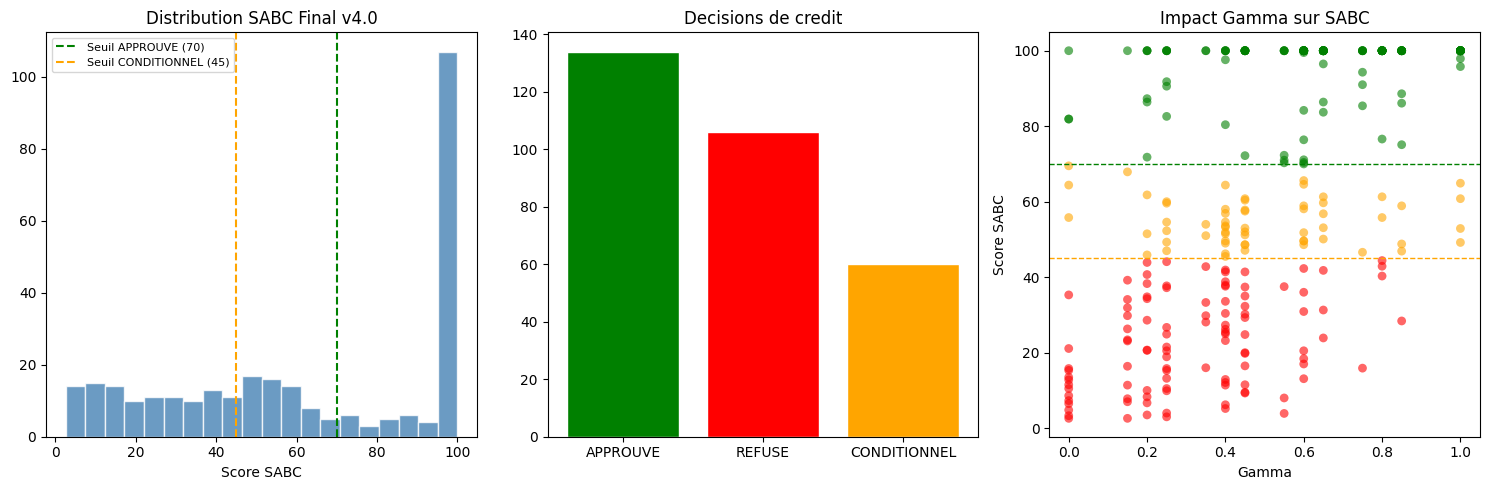

In [70]:
couleurs_dec={'APPROUVE':'green','CONDITIONNEL':'orange','REFUSE':'red'}
fig,axes=plt.subplots(1,3,figsize=(15,5))

axes[0].hist(ag_sabc['SABC_final'],bins=20,color='steelblue',edgecolor='white',alpha=0.8)
axes[0].axvline(70,color='green', ls='--',label='Seuil APPROUVE (70)')
axes[0].axvline(45,color='orange',ls='--',label='Seuil CONDITIONNEL (45)')
axes[0].set_title('Distribution SABC Final v4.0')
axes[0].set_xlabel('Score SABC'); axes[0].legend(fontsize=8)

dec=ag_sabc['Decision_finale'].value_counts()
axes[1].bar(dec.index,dec.values,color=[couleurs_dec[d] for d in dec.index],edgecolor='white')
axes[1].set_title('Decisions de credit')

axes[2].scatter(ag_sabc['Gamma'],ag_sabc['SABC_final'],
    c=ag_sabc['Decision_finale'].map(couleurs_dec),alpha=0.6,s=40,edgecolors='none')
axes[2].axhline(70,color='green', ls='--',lw=1)
axes[2].axhline(45,color='orange',ls='--',lw=1)
axes[2].set_xlabel('Gamma'); axes[2].set_ylabel('Score SABC')
axes[2].set_title('Impact Gamma sur SABC')

plt.tight_layout()
plt.savefig(os.path.join(PROC_PATH,'sabc_final.png'),dpi=150)
plt.show()

## Section 12 — Classification : Decision de credit

In [71]:
%pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [72]:
from imblearn.over_sampling import SMOTENC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.preprocessing import LabelEncoder
import numpy as np
import xgboost as xgb
import joblib
import os

le = LabelEncoder()
y_clf_all = le.fit_transform(ag['Decision_credit'])

# CORRECTION 1 : On supprime les éventuels doublons dans les colonnes
raw_features = feat_enc2 + ['VPD_moyen_saison','Jours_stress_thermique','Pluie_saison_mm','NDWI_moyen','Surface_barrage_specifique_norm']
feat_clf = []
for f in raw_features:
    if f in ag_enc2.columns and f not in feat_clf:
        feat_clf.append(f)

X_clf_all = ag_enc2[feat_clf].astype(float)

X_clf_tr, X_clf_te, y_clf_tr, y_clf_te = train_test_split(
    X_clf_all, y_clf_all, test_size=0.20, random_state=42, stratify=y_clf_all 
)

cat_feature_indices = [i for i, c in enumerate(feat_clf) if c.startswith(('Culture_','Type_Sol_','Localisation_'))]

smote = SMOTENC(
    categorical_features=cat_feature_indices, k_neighbors=3,
    sampling_strategy={ le.transform(['CONDITIONNEL'])[0]: 80 }, random_state=42
)
X_tr_resampled, y_tr_resampled = smote.fit_resample(X_clf_tr, y_clf_tr)

clf = xgb.XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, random_state=42,
    n_jobs=-1, verbosity=0, eval_metric='mlogloss'
)

# CORRECTION 2 : On force le format NumPy Array pour contourner le bug XGBoost/Pandas
clf.fit(np.array(X_tr_resampled), np.array(y_tr_resampled))

proba_test = clf.predict_proba(X_clf_te.to_numpy())
SEUIL_CONDITIONNEL = 0.30
cond_idx = list(le.classes_).index('CONDITIONNEL')
y_clf_pred = np.argmax(proba_test, axis=1)
y_clf_pred[proba_test[:, cond_idx] > SEUIL_CONDITIONNEL] = cond_idx

print(classification_report(y_clf_te, y_clf_pred, target_names=le.classes_))

joblib.dump({
    'model': clf, 'label_encoder': le, 'feature_names': feat_clf,
    'thresholds': {'CONDITIONNEL': SEUIL_CONDITIONNEL}, 'classes': list(le.classes_)
}, os.path.join(MODEL_PATH, 'xgboost_credit_v5.pkl'))

              precision    recall  f1-score   support

    APPROUVE       0.73      0.76      0.75        25
CONDITIONNEL       0.15      0.29      0.20         7
      REFUSE       0.95      0.71      0.82        28

    accuracy                           0.68        60
   macro avg       0.61      0.59      0.59        60
weighted avg       0.77      0.68      0.71        60



['C:\\Users\\ouakk\\Desktop\\AvoRuby_Temp\\AvoRuby_Cash_Project\\notebooks\\..\\models\\xgboost_credit_v5.pkl']

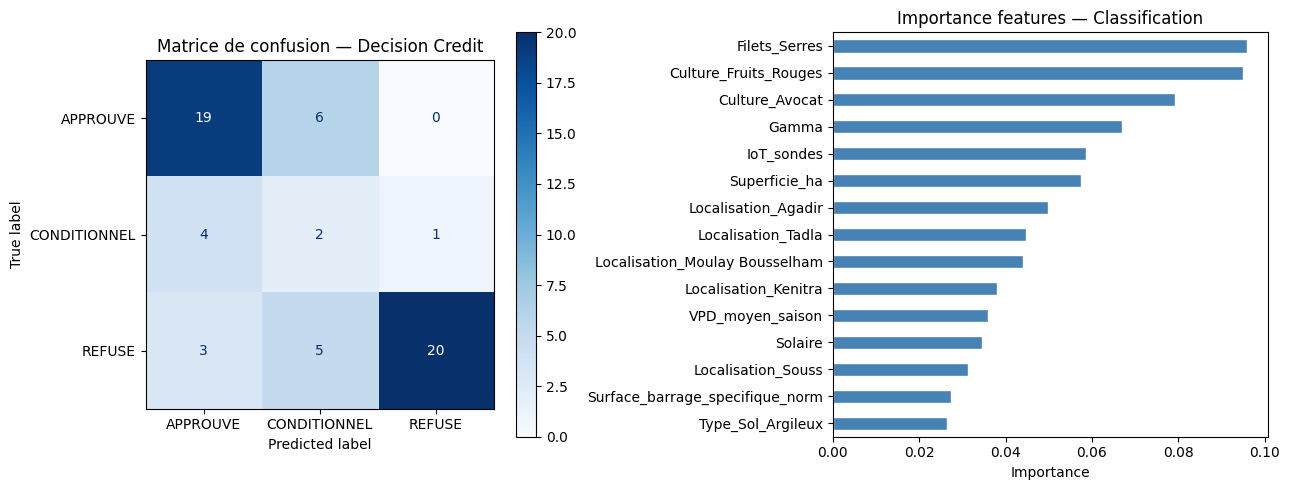

Classificateur sauvegarde


In [73]:
fig,axes=plt.subplots(1,2,figsize=(13,5))

cm=confusion_matrix(y_clf_te,y_clf_pred)
disp=ConfusionMatrixDisplay(cm,display_labels=le.classes_)
disp.plot(cmap='Blues',ax=axes[0])
axes[0].set_title('Matrice de confusion — Decision Credit')

feat_imp=pd.Series(clf.feature_importances_,index=feat_clf).sort_values(ascending=True).tail(15)
feat_imp.plot(kind='barh',ax=axes[1],color='steelblue',edgecolor='white')
axes[1].set_title('Importance features — Classification')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.savefig(os.path.join(PROC_PATH,'confusion_matrix.png'),dpi=150)
plt.show()

joblib.dump(clf,os.path.join(MODEL_PATH,'xgboost_credit.pkl'))
joblib.dump(le, os.path.join(MODEL_PATH,'label_encoder.pkl'))
print('Classificateur sauvegarde')

## Section 13 — Recapitulatif global

In [74]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# 1. Calcul des métriques de classification manquantes (en macro pour bien voir l'effet sur la classe CONDITIONNEL)
acc  = accuracy_score(y_clf_te, y_clf_pred)
f1   = f1_score(y_clf_te, y_clf_pred, average='macro')
prec = precision_score(y_clf_te, y_clf_pred, average='macro', zero_division=0)
rec  = recall_score(y_clf_te, y_clf_pred, average='macro', zero_division=0)

# 2. Affichage du récapitulatif
print('='*55)
print('RECAPITULATIF AVORUBY CASH v4.1')
print('='*55)

print('\n--- TIME SERIES VPD J+7 ---')
print(recap_vpd[['Modele','Echelle','MAE','RMSE','R2','MAPE','MBE','Pearson']].to_string(index=False))

print('\n--- NDWI J+30 (SARIMA mensuel) ---')
print(f"  MAE={metrics_ndwi['MAE']:.4f} | R2={metrics_ndwi['R2']:.4f} | Pearson={metrics_ndwi['Pearson']:.4f}")

print('\n--- PRODUCTION (XGBoost) ---')
print(f"  MAE={metrics_prod['MAE']:.0f} kg/ha | R2={metrics_prod['R2']:.4f} | MAPE={metrics_prod['MAPE']:.2f}%")

print('\n--- CLASSIFICATION ---')
print(f'  Accuracy={acc:.4f} | F1={f1:.4f} | Precision={prec:.4f} | Recall={rec:.4f}')

print('\n--- AMELIORATIONS v4.1 ---')
print('  Barrage GPS specifique par localisation (Haversine)')
print('  NDWI delta : delta_3mois / delta_6mois (coherent mensuel)')
print('  Comparaison VPD corrigee (echelles distinctes)')
print('  63 features exactes (pas 60)')
print('  [NOUVEAU] SMOTENC + TimeSeriesSplit + Score Gamma proportionnel')

print('\nModeles sauvegardes:')
print(sorted(os.listdir(MODEL_PATH)))

RECAPITULATIF AVORUBY CASH v4.1

--- TIME SERIES VPD J+7 ---
        Modele Echelle    MAE   RMSE     R2    MAPE     MBE  Pearson
SARIMA (hebdo)   hebdo 0.1966 0.2575 0.9290 17.4495  0.0898   0.9685
       XGBoost  quotid 0.1915 0.2504 0.9344 17.1984  0.0489   0.9680
  LSTM PyTorch  quotid 0.1728 0.2376 0.9448 13.6235 -0.0268   0.9727

--- NDWI J+30 (SARIMA mensuel) ---
  MAE=0.0140 | R2=0.3082 | Pearson=0.6684

--- PRODUCTION (XGBoost) ---
  MAE=1287 kg/ha | R2=0.5708 | MAPE=13.22%

--- CLASSIFICATION ---
  Accuracy=0.6833 | F1=0.5871 | Precision=0.6123 | Recall=0.5867

--- AMELIORATIONS v4.1 ---
  Barrage GPS specifique par localisation (Haversine)
  NDWI delta : delta_3mois / delta_6mois (coherent mensuel)
  Comparaison VPD corrigee (echelles distinctes)
  63 features exactes (pas 60)
  [NOUVEAU] SMOTENC + TimeSeriesSplit + Score Gamma proportionnel

Modeles sauvegardes:
['label_encoder.pkl', 'lstm_vpd.pt', 'nlp_metadata.json', 'nlp_pipeline.pkl', 'nlp_templates.json', 'sarima_ndwi.

## Section 14 — Sélection automatique des meilleurs modèles → 

Le notebook garde **toutes** ses comparaisons et images.  
Cette cellule choisit automatiquement le **meilleur modèle** par tâche (selon R²)  
et copie uniquement les fichiers nécessaires dans .

In [75]:
import shutil
import os
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error

# Sécurité : Recréation rapide de metrics_prix si la cellule précédente n'a pas été exécutée
if 'metrics_prix' not in globals() or not metrics_prix:
    metrics_prix = {}
    for culture, features, col_cible in [('Avocat', features_avocat, 'avocat_prix_mad_kg'), 
                                         ('Fruits_Rouges', features_ruby, 'ruby_prix_mad_kg')]:
        X_m = marche_clean[features].astype(float).to_numpy()
        y_m = marche_clean[col_cible].to_numpy()
        y_pred = mdl_prix[culture].predict(X_m)
        metrics_prix[culture] = {'R2': r2_score(y_m, y_pred), 'MAE': mean_absolute_error(y_m, y_pred)}

FLASK_PATH = os.path.join(BASE_PATH, '..', 'models_flask')
os.makedirs(FLASK_PATH, exist_ok=True)

# ── 1. Meilleur modèle VPD (comparaison SARIMA vs XGBoost vs LSTM) ────────────
vpd_candidats = {
    'XGBoost VPD': {
        'r2':    metrics_xgb_vpd['R2'],
        'mae':   metrics_xgb_vpd['MAE'],
        'files': {
            'xgboost_vpd.pkl': 'XGBoost VPD principal',
        }
    },
    'LSTM PyTorch': {
        'r2':    metrics_lstm['R2'],
        'mae':   metrics_lstm['MAE'],
        'files': {
            'lstm_vpd.pt':        'LSTM weights',
            'scaler_X_lstm.pkl':  'Normalisation input',
            'scaler_y_lstm.pkl':  'Dénormalisation output',
        }
    }
}

meilleur_vpd = max(vpd_candidats, key=lambda k: vpd_candidats[k]['r2'])
print('━'*60)
print('VPD J+7 — Comparaison modèles quotidiens :')
for nom, info in vpd_candidats.items():
    flag = '✅ SÉLECTIONNÉ' if nom == meilleur_vpd else '    '
    print(f'  {flag}  {nom:<20} R²={info["r2"]:.4f} | MAE={info["mae"]:.4f} kPa')

# ── 2. NDWI — SARIMA uniquement (pas de comparaison) ─────────────────────────
print()
print('━'*60)
print('NDWI J+30 — SARIMA uniquement :')
print(f'  ✅ SARIMA NDWI   R²={metrics_ndwi["R2"]:.4f} | MAE={metrics_ndwi["MAE"]:.4f}')

# ── 3. Prix — XGBoost uniquement ─────────────────────────────────────────────
print()
print('━'*60)
print('Prix MAD/kg — XGBoost uniquement :')
for culture in ['Avocat', 'Fruits_Rouges']:
    if culture in metrics_prix and metrics_prix[culture]:
        m = metrics_prix[culture]
        print(f'  ✅ XGBoost Prix {culture:<20} R²={m.get("R2",0):.4f} | MAE={m.get("MAE",0):.4f}')
    else:
        print(f'  ✅ XGBoost Prix {culture} (jeu test trop petit pour évaluation)')

# ── 4. Production + Crédit ────────────────────────────────────────────────────
print()
print('━'*60)
print('Production kg/ha — XGBoost uniquement :')
print(f'  ✅ XGBoost Production   R²={metrics_prod["R2"]:.4f} | MAE={metrics_prod["MAE"]:.0f} kg/ha')
print()
print('━'*60)
print('Décision Crédit — XGBoost Classifier :')
print(f'  ✅ XGBoost Credit   Accuracy={acc:.4f} | F1={f1:.4f}')

# ── 5. Copie dans models_flask/ ───────────────────────────────────────────────
print()
print('━'*60)
print('COPIE → models_flask/')
print('━'*60)

to_copy = {}

# VPD : meilleur modèle sélectionné
for fname, role in vpd_candidats[meilleur_vpd]['files'].items():
    to_copy[fname] = f'VPD J+7 [{meilleur_vpd}] — {role}'

# NDWI : SARIMA
to_copy['sarima_ndwi.pkl'] = 'NDWI J+30 [SARIMA]'

# Prix
to_copy['xgboost_prix_avocat.pkl']        = 'Prix Avocat MAD/kg [XGBoost]'
to_copy['xgboost_prix_fruits_rouges.pkl'] = 'Prix Fruits Rouges MAD/kg [XGBoost]'

# Production
to_copy['xgboost_production.pkl'] = 'Rendement kg/ha [XGBoost]'

# Crédit : Mise à jour vers le fichier v5 packagé qui contient aussi le LabelEncoder
to_copy['xgboost_credit_v5.pkl'] = 'Package Crédit complet [Modèle + LabelEncoder + Seuils] (v5)'

total_size = 0
for fname, role in to_copy.items():
    src  = os.path.join(MODEL_PATH, fname)
    dest = os.path.join(FLASK_PATH, fname)
    if os.path.exists(src):
        shutil.copy2(src, dest)
        size = os.path.getsize(dest) / 1024
        total_size += size
        print(f'  ✓ {fname:<42} {size:6.1f} KB')
        print(f'     → {role}')
    else:
        print(f'  ❌ {fname:<42} MANQUANT')

print()
print(f'  {len(to_copy)} fichiers | {total_size:.1f} KB total')
print(f'  Dossier : {os.path.abspath(FLASK_PATH)}')
print()
print('⚠️  Non copiés (comparaison notebook uniquement) :')
not_flask = [f for f in os.listdir(MODEL_PATH) if f not in to_copy]
for f in sorted(not_flask):
    size = os.path.getsize(os.path.join(MODEL_PATH,f))/1024
    print(f'    ✗ {f} ({size:.1f} KB)')
print()
print('✅ models_flask/ prêt pour Flask !')
print('   → Dans model.py : MODEL_PATH = "models_flask/"')


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
VPD J+7 — Comparaison modèles quotidiens :
        XGBoost VPD          R²=0.9344 | MAE=0.1915 kPa
  ✅ SÉLECTIONNÉ  LSTM PyTorch         R²=0.9448 | MAE=0.1728 kPa

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
NDWI J+30 — SARIMA uniquement :
  ✅ SARIMA NDWI   R²=0.3082 | MAE=0.0140

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Prix MAD/kg — XGBoost uniquement :
  ✅ XGBoost Prix Avocat               R²=0.7324 | MAE=2.7472
  ✅ XGBoost Prix Fruits_Rouges        R²=0.7243 | MAE=7.0661

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Production kg/ha — XGBoost uniquement :
  ✅ XGBoost Production   R²=0.5708 | MAE=1287 kg/ha

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Décision Crédit — XGBoost Classifier :
  ✅ XGBoost Credit   Accuracy=0.6833 | F1=0.5871

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
COPIE → models_flask/
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━